# --- FASE 1: CONFIGURAÇÃO DO AMBIENTE ---

In [1]:
!pip install wntr -q
!pip install plotly -q
!pip install tensorflow --upgrade -q

In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
# --- CONEXÃO COM O DRIVE ---

import os
from google.colab import drive

# 1. Estruturação de acesso ao drive
drive.mount('/content/drive')

# 2. Define o caminho da pasta a ser utilizada
caminho_pasta = '/content/drive/MyDrive/TCC_BattLeDIM'

# 3. Modifica o diretório de trabalho do Python para a pasta definida
os.chdir(caminho_pasta)

print(f"Diretório de trabalho atual: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Diretório de trabalho atual: /content/drive/MyDrive/TCC_BattLeDIM


In [4]:
# --- IMPORTAÇÃO DE BIBLIOTECAS ---

# 1. Bibliotecas Padrão e de Sistema
import sys, warnings, time

# 2. Manipulação de Dados e Numérico
import pandas as pd
import numpy as np

# 3. Visualização de Dados
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns

# 4. Simulação Hidráulica (Domínio do Problema)
import wntr

# 5. Machine Learning e Pré-processamento (Scikit-Learn)
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error, classification_report, accuracy_score, r2_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)
from sklearn.cluster import KMeans

# 6. Deep Learning (TensorFlow/Keras) - Uso do Keras para construir a arquitetura híbrida (CNN + LSTM)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers

# 7. Reprodutibilidade
import random

# Configurações de visualização
pd.set_option('display.max_columns', None)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [5]:
# --- VERSÕES DAS BIBLIOTECAS ---

print(f"Versão do Python: {sys.version.split()[0]}")
print(f"Versão do TensorFlow: {tf.__version__}")
print(f"Versão do WNTR: {wntr.__version__}")

# Verificar se a GPU está disponível (importante para o treinamento de Deep Learning)
gpu_info = tf.config.list_physical_devices('GPU')
if gpu_info:
    print(f"GPU Disponível: {gpu_info}")
else:
    print("GPU não detectada. O treinamento será mais lento (Rodando em CPU).")
    print("No Google Colab, vá em 'Runtime' > 'Change runtime type' e selecione T4 GPU.")

Versão do Python: 3.12.13
Versão do TensorFlow: 2.21.0
Versão do WNTR: 1.4.0
GPU não detectada. O treinamento será mais lento (Rodando em CPU).
No Google Colab, vá em 'Runtime' > 'Change runtime type' e selecione T4 GPU.


In [6]:
# --- CONFIGURAÇÃO DE REPRODUTIBILIDADE (SEED) ---
SEED_GLOBAL = 42

def reset_random_seeds(seed_value=SEED_GLOBAL):
    # 1. Define a seed para o ambiente Python
    os.environ['PYTHONHASHSEED'] = str(seed_value)

    # 2. Define a seed para o Python random
    random.seed(seed_value)

    # 3. Define a seed para o NumPy
    np.random.seed(seed_value)

    # 4. Define a seed para o TensorFlow
    tf.random.set_seed(seed_value)

    # 5. Define a seed para o processamento das épocas
    tf.config.experimental.enable_op_determinism()

    print(f"Seeds definidas globalmente para: {seed_value}")

reset_random_seeds()

Seeds definidas globalmente para: 42


## --- FASE 2: EXPLORAÇÃO DOS DADOS E CARREGAMENTO DO MODELO ---

A rede 'L-TOWN.inp' foi carregada.

--- Resumo dos Elementos da Rede ---
{'Nodes': {'Junctions': 782, 'Tanks': 1, 'Reservoirs': 2}, 'Links': {'Pipes': 905, 'Pumps': 1, 'Valves': 3}, 'Patterns': 3, 'Curves': {'Pump': 1, 'Efficiency': 0, 'Headloss': 0, 'Volume': 0}, 'Sources': 0, 'Controls': 2}


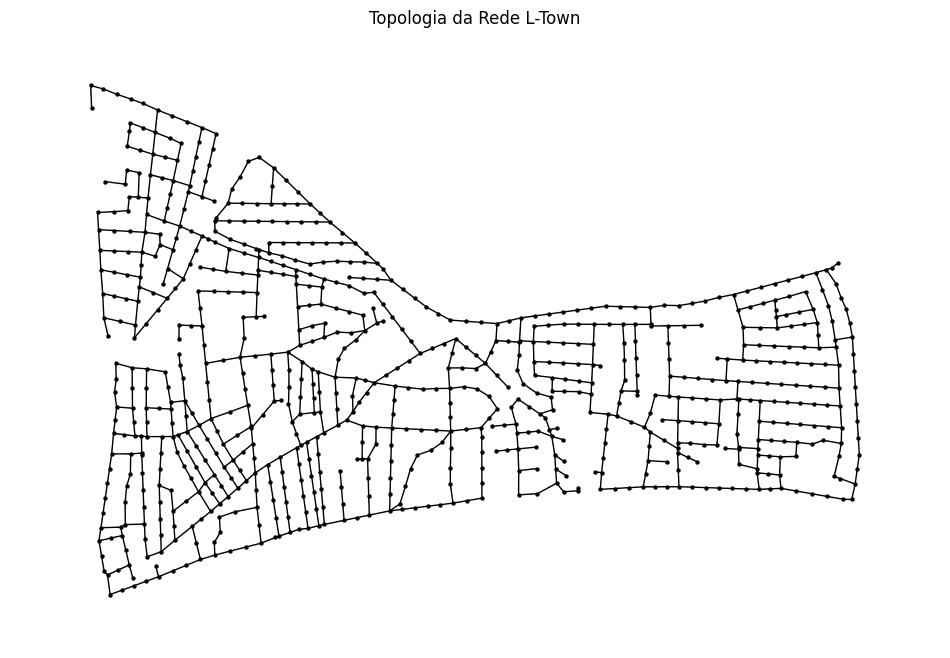

In [7]:
# --- CARREGAMENTO DA REDE E ANÁLISE INICIAL ---

inp_filename = 'L-TOWN.inp'

try:
    wn = wntr.network.WaterNetworkModel(inp_filename)
    print(f"A rede '{inp_filename}' foi carregada.")
    print("\n--- Resumo dos Elementos da Rede ---")
    for linha in str(wn.describe(level=1)).split("\n"):
        print(linha)

except FileNotFoundError:
    print(f"ERRO: O arquivo '{inp_filename}' não foi encontrado.")
    print("Verifique se você fez o upload para o Drive ou se mudou o diretório corretamente com 'os.chdir'.")

fig, ax = plt.subplots(figsize=(12, 8))
wntr.graphics.plot_network(wn, node_size=10, link_width=1, title='Topologia da Rede L-Town', ax=ax)
plt.show()

In [8]:
# --- CARREGAMENTO DOS DADOS DE PRESSÃO ---

pressure_file = '2018_SCADA_Pressures.csv'

try:
    df_pressure = pd.read_csv(pressure_file, index_col=0, parse_dates=True, sep=';', decimal=',')
    print("Dados de pressão carregados!")
    print(f"Dimensões do Dataset: {df_pressure.shape} (Linhas de tempo x Sensores)")
except FileNotFoundError:
    print(f"ERRO: Arquivo '{pressure_file}' não encontrado.")
    print("Verifique se o arquivo está na mesma pasta do script ou se o caminho está correto.")
except Exception as e:
    print(f"Ocorreu um erro ao ler o CSV: {e}")

print("="*30)
print("RESUMO DO PERÍODO TEMPORAL")
print("="*30)
data_inicio = df_pressure.index.min()
data_fim = df_pressure.index.max()
print(f"📅 Primeira Data (Início): {data_inicio}")
print(f"📅 Última Data (Fim):      {data_fim}")
print("="*30)

frequencia = df_pressure.index[1] - df_pressure.index[0]
print(f"Intervalo entre medições (Frequência): {frequencia}")

pontos_por_dia = 24 * 60 / (frequencia.seconds / 60)
print(f"Pontos necessários para cobrir 1 dia: {int(pontos_por_dia)}")

Dados de pressão carregados!
Dimensões do Dataset: (105120, 33) (Linhas de tempo x Sensores)
RESUMO DO PERÍODO TEMPORAL
📅 Primeira Data (Início): 2018-01-01 00:00:00
📅 Última Data (Fim):      2018-12-31 23:55:00
Intervalo entre medições (Frequência): 0 days 00:05:00
Pontos necessários para cobrir 1 dia: 288


## --- FASE 3: CARREGAMENTO DO DATASET DATASET SINTÉTICO ---





In [9]:
# --- CARREGAMENTO DO DATASET SINTÉTICO ---

DATA_DIR = '/content/drive/MyDrive/TCC_BattLeDIM/datasets'
arquivo = 'dataset_mix_materiais_10000.npz' # dataset_mix_materiais_5000.npz para 5.000 cenários | dataset_mix_materiais_10000.npz para 10.000 cenários | dataset_mix_materiais_10000_Flex para 85% dos materiais flexíveis

data = np.load(os.path.join(DATA_DIR, arquivo), allow_pickle=True)

X_tensor = data['X']
y_raw = data['y']
sensor_columns = data['sensors']

df_y = pd.DataFrame(
    y_raw,
    columns=['Leak_Node', 'Emitter_Coef']
)

print(f"Dataset {arquivo} carregado.")
print(data.files)
print("X:", X_tensor.shape)
print("y:", df_y.shape)
print("sensors:", sensor_columns.shape)
print("\n"+"="*40)
print("RESUMO DO DATASET CARREGADO")
print("="*40)
print(f"Total de Cenários:      {X_tensor.shape[0]}")
print(f"Passos Temporais:       {X_tensor.shape[1]}")
print(f"Número de Sensores:     {X_tensor.shape[2]}")
print("="*40)


Dataset dataset_mix_materiais_10000.npz carregado.
['X', 'y', 'sensors']
X: (10000, 96, 33)
y: (10000, 2)
sensors: (33,)

RESUMO DO DATASET CARREGADO
Total de Cenários:      10000
Passos Temporais:       96
Número de Sensores:     33


In [10]:
# --- VERIFICAÇÃO DO BALANCEAMENTO ESPACIAL DE NÓS COM VAZAMENTOS ---

contagem_nos = df_y['Leak_Node'].value_counts() # Valores distintos dos IDs dos nós cujos vazamentos foram simulados
nos_totais = wn.junction_name_list
print("--- Estatísticas de Geração Espacial ---")
print(f"Total de nós do modelo hidráulico: {len(nos_totais)}")
print(f"Total de nós com vazamento simulado: {len(contagem_nos)}")
print(f"Nó mais frequente: {contagem_nos.idxmax()} ({contagem_nos.max()} vezes)")
print(f"Nó menos frequente: {contagem_nos.idxmin()} ({contagem_nos.min()} vezes)")

if len(contagem_nos) < 0.9 * len(nos_totais): # Se testamos menos de 100 nós diferentes
    print("ALERTA: A diversidade espacial está baixa.")

--- Estatísticas de Geração Espacial ---
Total de nós do modelo hidráulico: 782
Total de nós com vazamento simulado: 782
Nó mais frequente: n665 (23 vezes)
Nó menos frequente: n725 (3 vezes)


## --- FASE 4: CONSTRUÇÃO E TREINAMENTO DO MODELO HÍBRIDO ---

Rede dividida em 10 zonas geográficas.


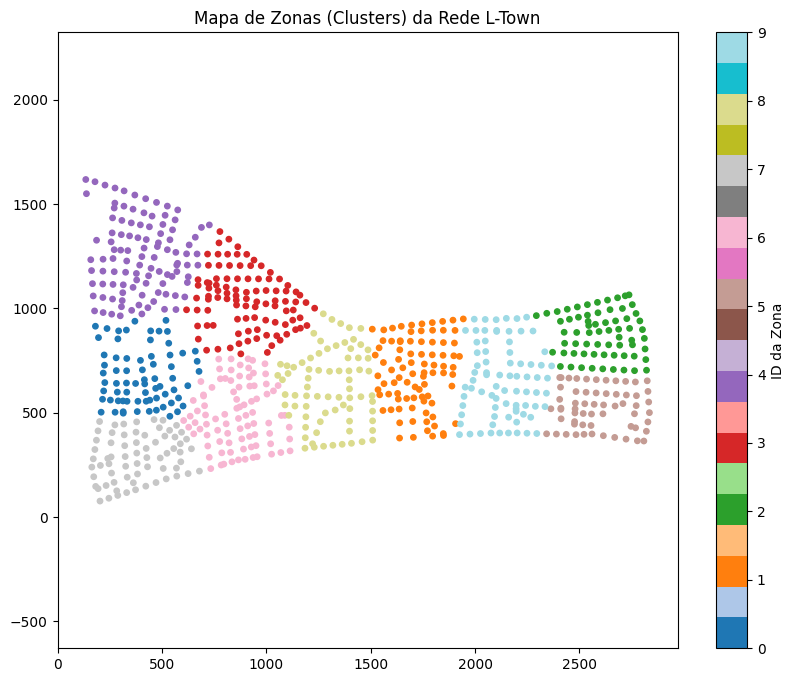

In [11]:
# --- DEFINIÇÃO DAS ZONAS A SEREM AVALIADAS ---

coords = []
node_ids = []

for node_name in wn.node_name_list:
    if node_name in wn.tank_name_list or node_name in wn.reservoir_name_list: # Excui da iteração os elementos reservoir e tank
        continue
    pos = wn.get_node(node_name).coordinates # Pega as coordenadas de cada nó (x, y) e guarda o ID
    coords.append(pos)
    node_ids.append(node_name)

df_coords = pd.DataFrame(coords, columns=['X', 'Y'], index=node_ids)

NUM_ZONAS = 10 # Número de Zonas em que o modelo deve ser subdividido (K-Means)
kmeans = KMeans(n_clusters=NUM_ZONAS, random_state=SEED_GLOBAL, n_init=10)
df_coords['Zona'] = kmeans.fit_predict(df_coords[['X', 'Y']])

print(f"Rede dividida em {NUM_ZONAS} zonas geográficas.")

def get_zone(node_name, fallback=-1):
    if node_name in df_coords.index:
        return df_coords.loc[node_name, 'Zona']
    return fallback

y_zones = df_y['Leak_Node'].apply(get_zone).values # Salva a informação em qual Zona está cada um dos vazamentos simulados no dataset sintético
y_coef = df_y['Emitter_Coef'].values

plt.figure(figsize=(10, 8))
plt.scatter(df_coords['X'], df_coords['Y'], c=df_coords['Zona'], cmap='tab20', s=15)
plt.colorbar(label='ID da Zona')
plt.title('Mapa de Zonas (Clusters) da Rede L-Town')
plt.axis('equal')
plt.show()

In [12]:
# --- PRÉ-PROCESSAMENTO 3D - RESÍDUOS E NORMALIZAÇÃO ---

DURATION = 24 * 3600
wn_base = wntr.network.WaterNetworkModel(inp_filename)
wn_base.options.time.duration = DURATION
wn_base.options.time.hydraulic_timestep = 900
wn_base.options.time.report_timestep = 900
sim_base = wntr.sim.EpanetSimulator(wn_base)
res_base = sim_base.run_sim() # Resultados do cenário base sem vazamentos

baseline_series = res_base.node['pressure'].loc[:, sensor_columns].iloc[1:97, :].values # Extração de dados apenas nos nós em que há sensor de pressão instalado (Shape: 96, 33)
X_residuals = X_tensor - baseline_series # Cálculo dos resíduos - Nessa etapa é subtraída a matriz (96,33) de cada item do tensor (N, 96, 33)

print(f"Resíduos calculados. Shape: {X_residuals.shape}")

N, T, F = X_residuals.shape # Amostras (N), Tempo (T), Features (F)
X_reshaped = X_residuals.reshape(N * T, F) # Normalização - Como a função "MinMaxScaler" espera um input 2D, é nescessário "achatar", normalizar e "desachatar"
scaler_X = MinMaxScaler()
X_scaled_flat = scaler_X.fit_transform(X_reshaped)
X_final_3D = X_scaled_flat.reshape(N, T, F)

print(f"Dados Normalizados. Exemplo [0,0,0]: {X_final_3D[0,0,0]:.4f}")

scaler_y = MinMaxScaler()
y_coef_norm = scaler_y.fit_transform(y_coef.reshape(-1, 1)) # Normalização do Coeficiente Emissor

print("Pré-processamento 3D concluído.")

Resíduos calculados. Shape: (10000, 96, 33)
Dados Normalizados. Exemplo [0,0,0]: 0.7797
Pré-processamento 3D concluído.


In [13]:
# --- ARQUITETURA HÍBRIDA (CNN + LSTM) ---

# 1. Separação da base (Mantendo estrutura temporal)
X_train, X_test, y_loc_train, y_loc_test, y_mag_train, y_mag_test = train_test_split(
    X_final_3D, y_zones, y_coef_norm, test_size=0.2, random_state=42
)

# 2. Definição da Arquitetura
input_shape = (96, 33) # 96 passos de tempo, 33 variáveis (sensores)
input_layer = layers.Input(shape=input_shape, name='Input_TimeSeries')

# --- BLOCO A: CNN-1D (Features Espaço-Temporais) ---
x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(input_layer) # Filters: 64 filtros aprendendo padrões | Kernel Size: 3 (olha janelas de 3 passos por vez)
x = layers.MaxPooling1D(pool_size=2)(x) # Reduz dimensionalidade
x = layers.Dropout(0.2)(x)

# --- BLOCO B: LSTM (Modelagem Sequencial) ---
x = layers.LSTM(50, return_sequences=False)(x) # Processa a sequência extraída pela CNN
x = layers.Dropout(0.2)(x)

# --- BLOCO C: Camadas Densas (Decisão) ---
x = layers.Dense(64, activation='relu')(x)

# Saídas (Multi-Task)
out_loc = layers.Dense(NUM_ZONAS, activation='softmax', name='Output_Localizacao')(x)
out_mag = layers.Dense(1, activation='linear', name='Output_Magnitude')(x)

# 3. Resumo
model_hybrid = models.Model(inputs=input_layer, outputs=[out_loc, out_mag])

model_hybrid.compile(
    optimizer='adam',
    loss={'Output_Localizacao': 'sparse_categorical_crossentropy', 'Output_Magnitude': 'mse'},
    loss_weights={'Output_Localizacao': 3.0, 'Output_Magnitude': 1.0},
    metrics={'Output_Localizacao': 'accuracy', 'Output_Magnitude': 'mae'})

model_hybrid.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_TimeSeries    │ (None, 96, 33)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 96, 64)    │      6,400 │ Input_TimeSeries… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 48, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50)        │     23,000 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      3,264 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Localizacao  │ (None, 10)        │        650 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Magnitude    │ (None, 1)         │         65 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,379 (130.39 KB)

 Trainable params: 33,379 (130.39 KB)

 Non-trainable params: 0 (0.00 B)

Iniciando treinamento da Rede Híbrida...
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - Output_Localizacao_accuracy: 0.1405 - Output_Localizacao_loss: 2.2815 - Output_Magnitude_loss: 0.0953 - Output_Magnitude_mae: 0.2599 - loss: 6.9398 - val_Output_Localizacao_accuracy: 0.1820 - val_Output_Localizacao_loss: 2.2491 - val_Output_Magnitude_loss: 0.0735 - val_Output_Magnitude_mae: 0.2290 - val_loss: 6.8236
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - Output_Localizacao_accuracy: 0.2400 - Output_Localizacao_loss: 2.0508 - Output_Magnitude_loss: 0.0792 - Output_Magnitude_mae: 0.2320 - loss: 6.2316 - val_Output_Localizacao_accuracy: 0.3750 - val_Output_Localizacao_loss: 1.6678 - val_Output_Magnitude_loss: 0.0548 - val_Output_Magnitude_mae: 0.1953 - val_loss: 5.0616
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - Output_Localizacao_accuracy: 0.3901 - Output_Localizacao_loss: 1.5620 - Output_Magnitude_loss: 0.0600 - Output_Magnitude_mae: 0.2001 - loss: 4.7461 - val_

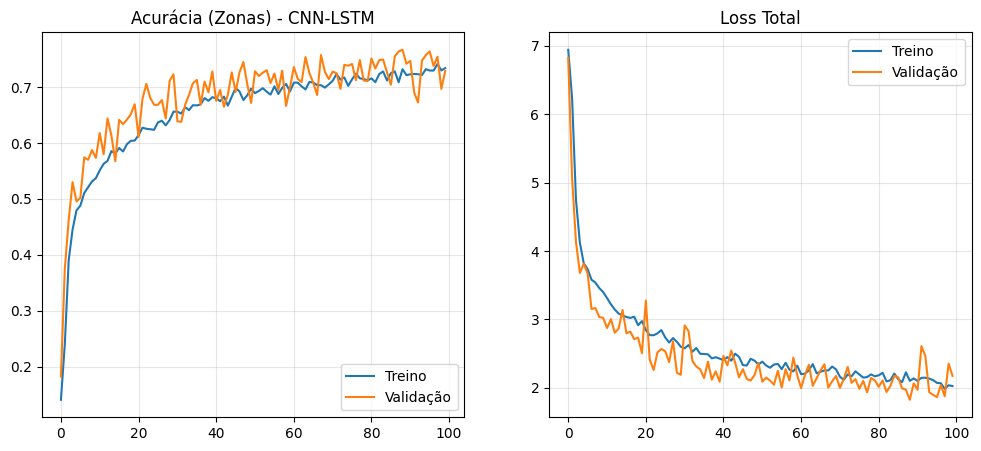

In [14]:
# --- TREINAMENTO DA ARQUITETURA HÍBRIDA (CNN + LSTM) ---

print("Iniciando treinamento da Rede Híbrida...")

history_hybrid = model_hybrid.fit(
    x=X_train,
    y={'Output_Localizacao': y_loc_train, 'Output_Magnitude': y_mag_train},
    validation_data=(X_test, {'Output_Localizacao': y_loc_test, 'Output_Magnitude': y_mag_test}),
    epochs=100,
    batch_size=256 if gpu_info else 64, #256 / 64
    verbose=1
)

print("Treinamento Concluído!")

plt.figure(figsize=(12, 5))

# Acurácia
plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['Output_Localizacao_accuracy'], label='Treino')
plt.plot(history_hybrid.history['val_Output_Localizacao_accuracy'], label='Validação')
plt.title('Acurácia (Zonas) - CNN-LSTM')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['loss'], label='Treino')
plt.plot(history_hybrid.history['val_loss'], label='Validação')
plt.title('Loss Total')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


## --- FASE 5: VALIDAÇÃO DOS RESULTADOS E MÉTRICAS OBTIDAS ---

Gerando sequências deslizantes (Isso pode levar 1 minuto)...
Rodando a CNN-LSTM nos dados reais...
411/411 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step


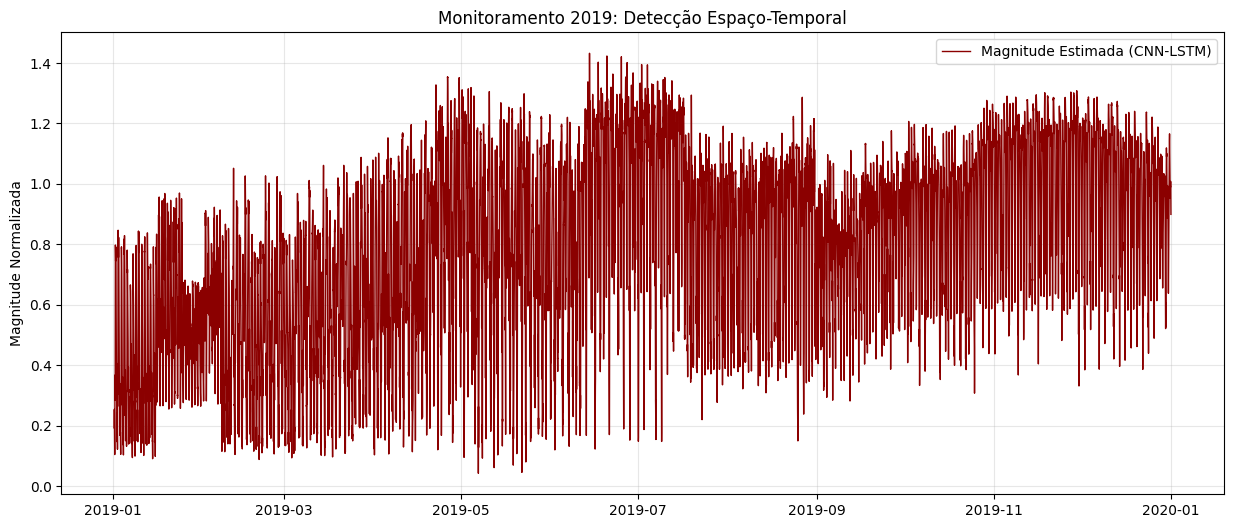

In [15]:
# --- VALIDAÇÃO RESULTADOS ---

# 1. Carregar 2019
df_2019 = pd.read_csv('2019_SCADA_Pressures.csv', index_col=0, parse_dates=True, sep=';', decimal=',')
df_2019 = df_2019[sensor_columns] # Filtrar sensores

df_2019 = df_2019.ffill().bfill().fillna(0)

# 2. Pré-processamento (Resíduos + Normalização)
baseline_mean_vector = baseline_series.mean(axis=0)
X_2019_residuals = df_2019 - baseline_mean_vector

# Normalizar
vals = X_2019_residuals.values
vals_scaled = scaler_X.transform(vals)

# 3. Criar Sequências (Janela Deslizante)
def create_sequences(data, seq_length):
    xs = []
    indexes = []
    for i in range(len(data) - seq_length):
        x = data[i:(i+seq_length)]
        xs.append(x)
        indexes.append(df_2019.index[i+seq_length])
    return np.array(xs), indexes

print("Gerando sequências deslizantes (Isso pode levar 1 minuto)...")

X_2019_seq, time_indexes = create_sequences(vals_scaled, seq_length=96)

if X_2019_seq.shape[1] != 96:
    raise ValueError(f"ERRO: A janela temporal está {X_2019_seq.shape[1]}, mas o modelo exige 96!")

print("Rodando a CNN-LSTM nos dados reais...")
pred_prob, pred_mag = model_hybrid.predict(X_2019_seq, batch_size=256, verbose=1)

# 4. Montar Resultados
results_2019 = pd.DataFrame({
    'Data': time_indexes,
    'Confianca': np.max(pred_prob, axis=1),
    'Magnitude_Estimada': pred_mag.flatten()
})

# 5. Plotar
plt.figure(figsize=(15, 6))
plt.plot(results_2019['Data'], results_2019['Magnitude_Estimada'].rolling(12).mean(),
         color='darkred', linewidth=1, label='Magnitude Estimada (CNN-LSTM)')
plt.title('Monitoramento 2019: Detecção Espaço-Temporal')
plt.ylabel('Magnitude Normalizada')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

📊 Calculando Métricas Finais e Gerando Gráficos para o TCC...
Mapa de coordenadas e zonas recuperado da memória.
Gerando predições no conjunto de teste...



--- 💧 1. Avaliação de Magnitude (Regressão) ---
R² (Coeficiente de Determinação): 0.8374  (Ideal > 0.8)
MAE (Erro Médio Absoluto):      0.0873
RMSE (Erro Quadrático Médio):   0.1174


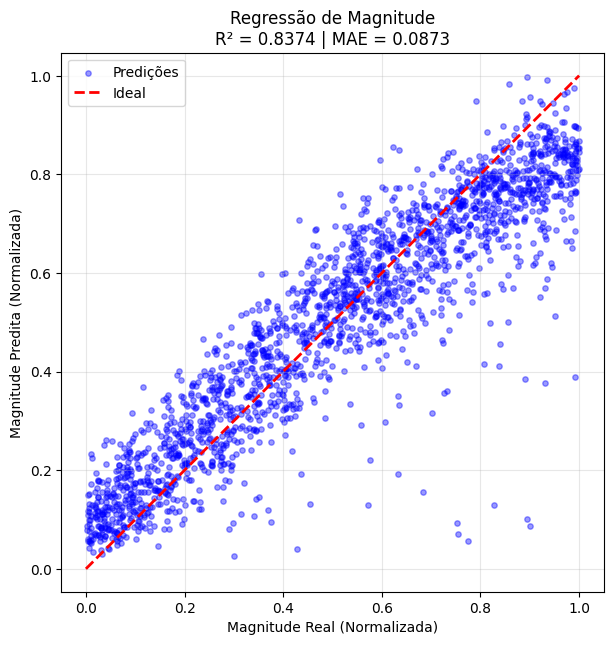


--- 📍 2. Avaliação de Localização e Detecção ---
Acurácia Global (Acerto exato de Zona): 72.90%
Precisão (Weighted):                    0.7585
Recall (Sensibilidade Weighted):        0.7290
F1-Score (Weighted):                    0.7186

Calculando erro médio de distância...
Erro Médio de Localização Espacial:   161.98 metros


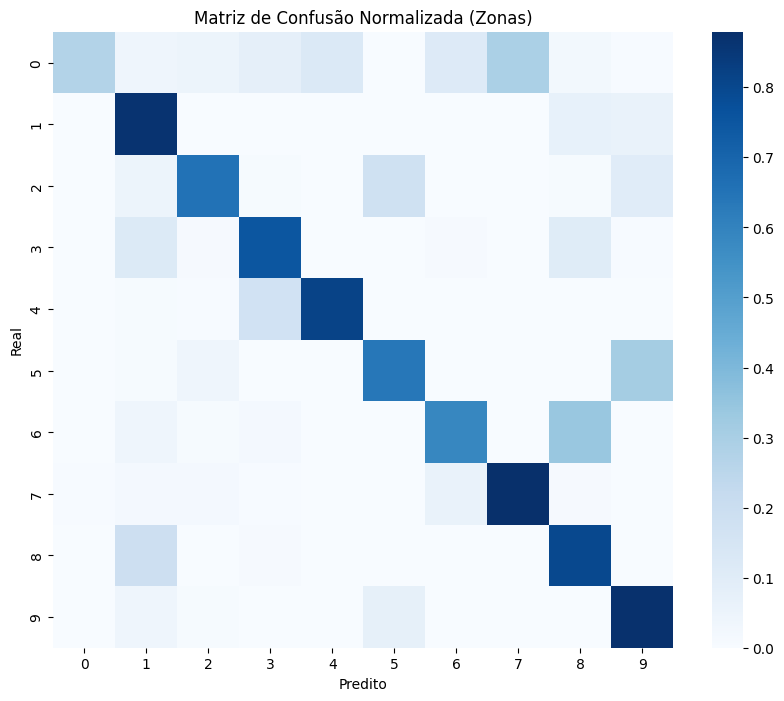


📈 AUC-ROC (Média Macro One-vs-Rest): 0.9708 (Ideal = 1.0)


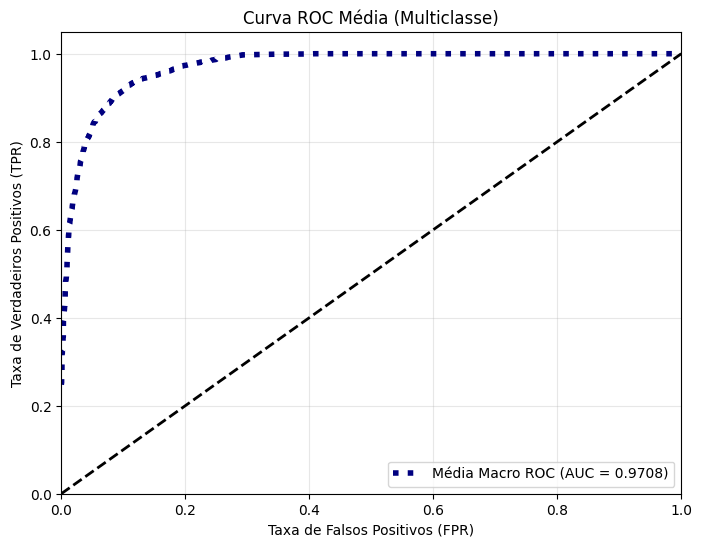


✅ Avaliação Completa Finalizada!


In [16]:
# --- AVALIAÇÃO CENÁRIO SINTÉTICO ---

print("📊 Calculando Métricas Finais e Gerando Gráficos para o TCC...")

# 1. Recuperar Coordenadas e Zonas
try:
    if 'Zona' not in df_coords.columns:
        raise ValueError("Coluna Zona não encontrada")
    print("Mapa de coordenadas e zonas recuperado da memória.")
except:
    print("⚠️ Regenerando mapa de coordenadas e zonas...")
    wn = wntr.network.WaterNetworkModel(inp_filename)
    coords = {}
    junctions_ids = [n for n in wn.node_name_list if n not in wn.tank_name_list and n not in wn.reservoir_name_list]
    for node in junctions_ids:
        coords[node] = wn.get_node(node).coordinates
    df_coords = pd.DataFrame.from_dict(coords, orient='index', columns=['X', 'Y'])
    df_coords['Zona'] = kmeans.predict(df_coords[['X', 'Y']]) # Usa o kmeans já treinado

# 2. Fazer Predições no Conjunto de Teste
print("Gerando predições no conjunto de teste...")
pred_probs, pred_mag = model_hybrid.predict(X_test, verbose=0)
pred_zones = np.argmax(pred_probs, axis=1)

print("\n--- 💧 1. Avaliação de Magnitude (Regressão) ---")

r2 = r2_score(y_mag_test, pred_mag)
mae = mean_absolute_error(y_mag_test, pred_mag)
rmse = np.sqrt(mean_squared_error(y_mag_test, pred_mag))

print(f"R² (Coeficiente de Determinação): {r2:.4f}  (Ideal > 0.8)")
print(f"MAE (Erro Médio Absoluto):      {mae:.4f}")
print(f"RMSE (Erro Quadrático Médio):   {rmse:.4f}")

# GRÁFICO 1: DISPERSÃO
plt.figure(figsize=(7, 7))
plt.scatter(y_mag_test, pred_mag, alpha=0.4, color='blue', s=15, label='Predições')
plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Ideal')
plt.xlabel('Magnitude Real (Normalizada)')
plt.ylabel('Magnitude Predita (Normalizada)')
plt.title(f'Regressão de Magnitude\nR² = {r2:.4f} | MAE = {mae:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.show()

print("\n--- 📍 2. Avaliação de Localização e Detecção ---")

acc = accuracy_score(y_loc_test, pred_zones)
prec = precision_score(y_loc_test, pred_zones, average='weighted', zero_division=0)
rec = recall_score(y_loc_test, pred_zones, average='weighted', zero_division=0)
f1 = f1_score(y_loc_test, pred_zones, average='weighted', zero_division=0)

print(f"Acurácia Global (Acerto exato de Zona): {acc:.2%}")
print(f"Precisão (Weighted):                    {prec:.4f}")
print(f"Recall (Sensibilidade Weighted):        {rec:.4f}")
print(f"F1-Score (Weighted):                    {f1:.4f}")

# Erro de Distância
print("\nCalculando erro médio de distância...")
zone_centroids = df_coords.groupby('Zona')[['X', 'Y']].mean().to_dict('index')
distances = []
for real_z, pred_z in zip(y_loc_test, pred_zones):
    try:
        real_xy = np.array([zone_centroids[real_z]['X'], zone_centroids[real_z]['Y']])
        pred_xy = np.array([zone_centroids[pred_z]['X'], zone_centroids[pred_z]['Y']])
        dist = np.linalg.norm(real_xy - pred_xy)
        distances.append(dist)
    except:
        pass

mean_dist_error = np.mean(distances)
print(f"Erro Médio de Localização Espacial:   {mean_dist_error:.2f} metros")

# GRÁFICO 2: MATRIZ DE CONFUSÃO
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_loc_test, pred_zones)
# Normaliza para visualizar melhor a proporção
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=False, cmap='Blues')
plt.title('Matriz de Confusão Normalizada (Zonas)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

# GRÁFICO 3: CURVA ROC
try:
    y_test_bin = label_binarize(y_loc_test, classes=range(NUM_ZONAS))
    auc_score = roc_auc_score(y_test_bin, pred_probs, multi_class='ovr', average='macro')
    print(f"\n📈 AUC-ROC (Média Macro One-vs-Rest): {auc_score:.4f} (Ideal = 1.0)")

    # Plotar Curva ROC Média
    from sklearn.metrics import roc_curve, auc
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(NUM_ZONAS):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_ZONAS)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(NUM_ZONAS):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= NUM_ZONAS

    plt.figure(figsize=(8, 6))
    plt.plot(all_fpr, mean_tpr, label=f'Média Macro ROC (AUC = {auc_score:.4f})', color='navy', linestyle=':', linewidth=4)
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (FPR)')
    plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
    plt.title('Curva ROC Média (Multiclasse)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"Aviso sobre ROC: {e}")

print("\n✅ Avaliação Completa Finalizada!")

## --- FASE 6: COMPARAÇÃO REAL VS PREDITO (GABARITO 2019) ---

🔍 1. Validação Temporal: Curva Real vs Predita...


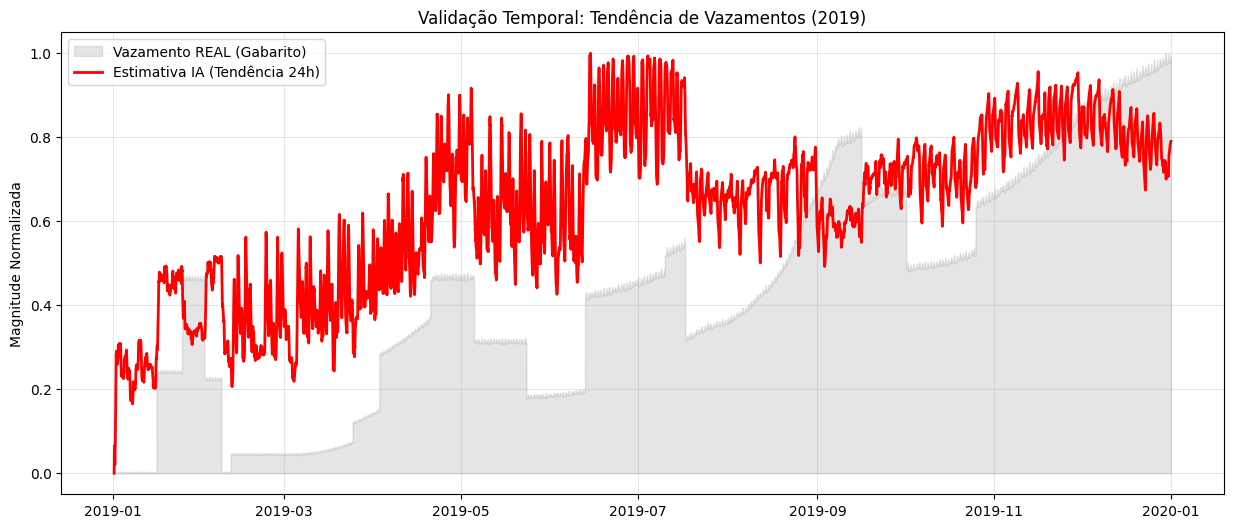

📊 Correlação Temporal (Pearson): 0.7367


In [17]:
# --- VALIDAÇÃO CRUZADA E VISUALIZAÇÃO FINAL (GABARITO 2019) ---

# Garantir que o modelo de rede WNTR esteja carregado
if 'wn' not in globals():
    wn = wntr.network.WaterNetworkModel(inp_filename)

print("🔍 1. Validação Temporal: Curva Real vs Predita...")

gabarito_file = '2019_Leakages.csv'

try:
    # Carrega Gabarito
    try:
        df_real_leaks = pd.read_csv(gabarito_file, index_col=0, sep=';', decimal=',')
    except:
        df_real_leaks = pd.read_csv(gabarito_file, index_col=0, sep=',')

    df_real_leaks.index = pd.to_datetime(df_real_leaks.index)

    # Soma vazamentos e reamostra para 15min
    total_leak_real = df_real_leaks.sum(axis=1).resample('15min').mean().fillna(0)

    # Prepara Predição
    results_2019['Data'] = pd.to_datetime(results_2019['Data'])
    df_pred_indexed = results_2019.set_index('Data').sort_index()

    # Interseção de Datas
    common_index = df_pred_indexed.index.intersection(total_leak_real.index)

    if len(common_index) > 0:
        real_curve = total_leak_real.loc[common_index]
        pred_curve = df_pred_indexed.loc[common_index, 'Magnitude_Estimada']

        # Normalizar para plotagem
        scaler_comp = MinMaxScaler()
        real_norm = scaler_comp.fit_transform(real_curve.values.reshape(-1, 1))

        # Suavização para facilitar visualização (Média Móvel 24h)
        pred_smooth = pred_curve.rolling(window=96, min_periods=1).mean().fillna(0).values # 96 steps = 24h
        pred_norm = scaler_comp.fit_transform(pred_smooth.reshape(-1, 1))

        # Plot
        plt.figure(figsize=(15, 6))
        plt.fill_between(common_index, real_norm.flatten(), color='gray', alpha=0.2, label='Vazamento REAL (Gabarito)')
        plt.plot(common_index, pred_norm, color='red', linewidth=2, label='Estimativa IA (Tendência 24h)')
        plt.title("Validação Temporal: Tendência de Vazamentos (2019)")
        plt.ylabel("Magnitude Normalizada")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # Correlação Pearson
        corr = pd.Series(real_norm.flatten()).corr(pd.Series(pred_norm.flatten()))
        print(f"📊 Correlação Temporal (Pearson): {corr:.4f}")
    else:
        print("❌ Sem datas em comum entre Gabarito e Predição.")

except Exception as e:
    print(f"Erro na Validação Temporal: {e}")

In [20]:
# --- VALIDAÇÃO ESPACIAL (GABARITO 2019) ---

print("🔍 Iniciando Validação de Localização (Gabarito 2019)...")

try:
    cols_prob = [c for c in results_2019.columns if c.startswith('Zona_') and 'Predita' not in c]

    if len(cols_prob) > 0:
        # Pega o índice da coluna com maior valor e remove o texto "Zona_" para ficar só o número
        results_2019['Zona_Predita'] = results_2019[cols_prob].idxmax(axis=1).str.replace('Zona_', '').astype(int)
        print("✅ Coluna 'Zona_Predita' gerada com sucesso.")
    else:
        # Se não achar as colunas de probabilidade, tenta usar a predição direta se já tiver sido feita
        if 'Zona_Predita' not in results_2019.columns:
             # Recalcula usando o modelo se necessário (Fallback)
             print("⚠️ Recalculando zonas preditas...")
             pred_probs, _ = model_hybrid.predict(X_2019_seq, batch_size=256, verbose=0)
             # Ajustar tamanho do indice se necessário (devido à janela deslizante)
             cut = len(results_2019) - len(pred_probs)
             results_2019 = results_2019.iloc[cut:]
             results_2019['Zona_Predita'] = np.argmax(pred_probs, axis=1)

    # 2. Carregar Gabarito Real (Se não estiver na memória)
    if 'df_real_leaks' not in globals():
        df_real_leaks = pd.read_csv('2019_Leakages.csv', index_col=0, parse_dates=True, sep=';', decimal=',')

    # 3. Achar o "Vilão" (O tubo que mais vazou no ano)
    total_leak_per_pipe = df_real_leaks.sum(axis=0)
    top_leak_pipe = total_leak_per_pipe.idxmax()
    max_vol = total_leak_per_pipe.max()

    print(f"🚨 Tubo com maior vazamento em 2019: {top_leak_pipe} (Total: {max_vol:.2f} m3)")

    # 4. Descobrir a Zona Real desse tubo
    wn = wntr.network.WaterNetworkModel(inp_filename)
    pipe = wn.get_link(top_leak_pipe)
    node_target = pipe.start_node_name # Pega o nó inicial do tubo

    # Busca a zona no nosso mapa (df_coords)
    if node_target in df_coords.index:
        real_zone = df_coords.loc[node_target, 'Zona']
        print(f"📍 Localização Real: ZONA {real_zone}")
    else:
        print(f"⚠️ Nó {node_target} não encontrado no mapeamento de zonas.")
        real_zone = -1

    # 5. Comparar com a IA no dia do pico
    peak_date = df_real_leaks[top_leak_pipe].idxmax()
    print(f"📅 Data do pico do vazamento: {peak_date}")

    # Janela de +/- 2 dias ao redor do pico
    start = peak_date - pd.Timedelta(days=2)
    end = peak_date + pd.Timedelta(days=2)

    mask = (results_2019['Data'] >= start) & (results_2019['Data'] <= end)
    subset = results_2019.loc[mask]

    if not subset.empty:
        ia_zone = subset['Zona_Predita'].mode()[0]
        confianca = subset['Confianca'].mean()

        print(f"🤖 O modelo indicou principalmente: ZONA {ia_zone}")
        print(f"   (Confiança média: {confianca:.2%})")

        if int(ia_zone) == int(real_zone):
            print("\n🏆 SUCESSO! O modelo acertou a zona exata do vazamento real.")
        else:
            if 'zone_centroids' in globals():
                rz, pz = int(real_zone), int(ia_zone)
                p1 = np.array([zone_centroids[rz]['X'], zone_centroids[rz]['Y']])
                p2 = np.array([zone_centroids[pz]['X'], zone_centroids[pz]['Y']])
                dist = np.linalg.norm(p1 - p2)
                print(f"\n📏 Distância entre Zona Real e Predita: {dist:.2f} metros")

                if dist < 400:
                    print("✅ Resultado Positivo: O modelo indicou uma zona vizinha/próxima.")
                else:
                    print("❌ O modelo errou a localização por uma margem grande.")
    else:
        print("⚠️ Sem dados de predição para a data do pico.")

except Exception as e:
    print(f"Erro no Bloco 16: {e}")

🔍 Iniciando Validação de Localização (Gabarito 2019)...
🚨 Tubo com maior vazamento em 2019: p331 (Total: 776290.76 m3)
📍 Localização Real: ZONA 3
📅 Data do pico do vazamento: 2019-05-29 03:40:00
🤖 O modelo indicou principalmente: ZONA 3
   (Confiança média: 79.33%)

🏆 SUCESSO! O modelo acertou a zona exata do vazamento real.


📊 Iniciando Cálculo de Métricas Definitivas para o Ano de 2019...
Mapeando tubos para zonas...
Gerando série temporal de zonas reais (Ground Truth)...
Horas com vazamentos ativos avaliadas: 105120

   RESULTADOS FINAIS - VALIDAÇÃO REAL 2019
1. Acurácia de Zona (Exact Match):  17.36%
   (Capacidade de dizer ONDE vaza - Zona Exata)
----------------------------------------
2. Erro Médio de Distância:         734.26 metros
   (Distância média entre o vazamento real e o predito)


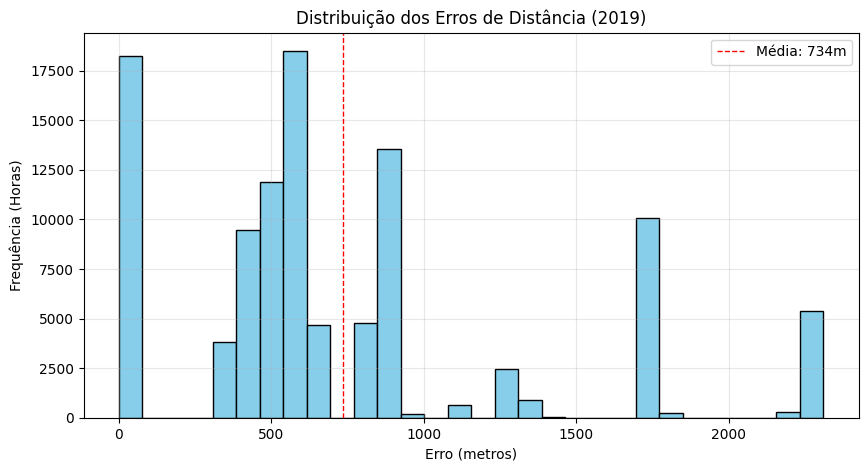

In [22]:
# --- MÉTRICAS - CENÁRIO DE COMPARAÇÃO COM GABARITO DE 2019 ---

print("📊 Iniciando Cálculo de Métricas Definitivas para o Ano de 2019...")

try:
    if 'df_real_leaks' not in globals():
        df_real_leaks = pd.read_csv('2019_Leakages.csv', index_col=0, parse_dates=True, sep=';', decimal=',')

    wn = wntr.network.WaterNetworkModel(inp_filename)
    pipe_to_zone = {}

    print("Mapeando tubos para zonas...")
    for link_name in wn.link_name_list:
        try:
            node = wn.get_link(link_name).start_node_name
            if node in df_coords.index:
                pipe_to_zone[link_name] = df_coords.loc[node, 'Zona']
        except:
            continue

    print("Gerando série temporal de zonas reais (Ground Truth)...")


    max_leak_pipes = df_real_leaks.idxmax(axis=1)
    real_zones_series = max_leak_pipes.map(pipe_to_zone)
    total_leak = df_real_leaks.sum(axis=1)
    real_zones_series[total_leak < 0.05] = -1

    df_eval = pd.DataFrame({
        'Real_Zone': real_zones_series,
        'Total_Leak_Vol': total_leak
    })

    if 'Data' in results_2019.columns:
        results_2019['Data'] = pd.to_datetime(results_2019['Data'])
        df_merged = pd.merge_asof(df_eval.sort_index(), results_2019.sort_values('Data'),
                                  left_index=True, right_on='Data', direction='nearest')
    else:
        df_merged = pd.merge_asof(df_eval.sort_index(), results_2019.sort_index(),
                                  left_index=True, right_index=True, direction='nearest')

    df_active_leaks = df_merged[df_merged['Real_Zone'] != -1].dropna()

    print(f"Horas com vazamentos ativos avaliadas: {len(df_active_leaks)}")

    # A. Acurácia de Zona (Exact Match)
    y_true = df_active_leaks['Real_Zone'].astype(int)
    y_pred = df_active_leaks['Zona_Predita'].astype(int)

    acc_real = accuracy_score(y_true, y_pred)

    # B. Erro de Distância (Distance Error)
    zone_centroids = df_coords.groupby('Zona')[['X', 'Y']].mean().to_dict('index')
    distances = []

    for r, p in zip(y_true, y_pred):
        if r in zone_centroids and p in zone_centroids:
            p_real = np.array([zone_centroids[r]['X'], zone_centroids[r]['Y']])
            p_pred = np.array([zone_centroids[p]['X'], zone_centroids[p]['Y']])
            distances.append(np.linalg.norm(p_real - p_pred))

    mean_dist_real = np.mean(distances)

    # C. Correlação de Magnitude (Pearson) | Compara o volume real (m3/h) com a magnitude estimada (0-1) - Usando o df_merged completo (com ou sem vazamento) para ver a tendência
    corr_mag = df_merged['Total_Leak_Vol'].corr(df_merged['Magnitude_Estimada'])

    # --- RELATÓRIO FINAL ---
    print("\n" + "="*40)
    print("   RESULTADOS FINAIS - VALIDAÇÃO REAL 2019")
    print("="*40)
    print(f"1. Acurácia de Zona (Exact Match):  {acc_real:.2%}")
    print(f"   (Capacidade de dizer ONDE vaza - Zona Exata)")
    print("-" * 40)
    print(f"2. Erro Médio de Distância:         {mean_dist_real:.2f} metros")
    print(f"   (Distância média entre o vazamento real e o predito)")
    print("="*40)

    # Histograma dos erros de distância
    plt.figure(figsize=(10, 5))
    plt.hist(distances, bins=30, color='skyblue', edgecolor='black')
    plt.title('Distribuição dos Erros de Distância (2019)')
    plt.xlabel('Erro (metros)')
    plt.ylabel('Frequência (Horas)')
    plt.axvline(mean_dist_real, color='red', linestyle='dashed', linewidth=1, label=f'Média: {mean_dist_real:.0f}m')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"Erro no cálculo: {e}")
    import traceback
    traceback.print_exc()

# **FIM!!!**